# Support Ticket Clustering

In this notebook, we analyze a dataset of support tickets in order to create clusters, which will be assigned to the proper support team.

## Plan

Convert the tickets subject + body into embeddings to train a unsupervised clustering model. Thus, use a local use a local LLM to obtain a description per cluster as well as a TF-IDF analysis to extract representative keywords.

1. TF-IDF analysis for cleaning boilerplate and noise.

## Packages

In [75]:
# Data handling
import json
import re
from collections import Counter

import numpy as np
import pandas as pd

# Text vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Plotting
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bruno.santos\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Settings

In [76]:
# Matplotlib settings
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 90)

# Shared tokenizer pattern: accent-aware words of 2+ characters.
TOKEN_PATTERN = r"(?u)\b\w\w+\b"
TOKEN_STOPWORDS = stopwords.words("portuguese")

## Dataset basic exploration

In [86]:
DATASET_PATH = 'dataset/classificacao_atendimento.csv'

tickets_df = pd.read_csv(DATASET_PATH, sep=',', encoding='utf-8')
NUMBER_DOCS = len(tickets_df)
tickets_df

,ticket_id,subject,body
0,2,Erro na Autocompletação de Código do IntelliJ IDEA,"Prezado Suporte ao Cliente <name>,\n\nEstou escrevendo para trazer à sua atenção um pr..."
1,28,Problemas intermitentes de exibição após atualização de firmware,"Caro Suporte ao Cliente,\n\n Estou entrando em contato para relatar um problema com me..."
2,45,Pedido de Assistência para Administração de Servidores,"Prezado Suporte ao Cliente de Serviços de TI,\n\nEspero que esta mensagem o encontre b..."
3,46,NaN,"Prezado <name>,\n\nSentimos muito ao saber sobre o atraso na entrega do seu Apple Watc..."
4,63,Urgente: Relato de Falha na Bateria do MacBook Air M1 Adquirido na Loja Virtual,"Prezado Atendimento ao Cliente,<br><br>Recentemente adquiri um MacBook Air M1 em sua l..."
...,...,...,...
468,3980,Incidente de alta prioridade,"Caro Time de Suporte ao Cliente,\n\nEspero que esta mensagem o encontre bem. Estou esc..."
469,3983,Urgente: Interrupção de Serviço da AWS,"Caro time de Suporte de Serviços de TI,\n\nEstou entrando em contato para relatar uma ..."
470,3988,Problema de Cobrança: Cobranças Incorretas na Assinatura,"Caro Equipe de Suporte ao Cliente,\n\nEstou escrevendo para trazer à sua atenção uma d..."
471,3994,Assistência Necessária para Problema de Tela do Dell XPS 13,"Caro Time de Suporte ao Cliente, estou enfrentando um problema de cintilação na tela d..."


Check whether the ticket ID column is unique. If yes, convert it to the Dataframe index.

In [8]:
tickets_df["ticket_id"].is_unique

True

The checking above confirms that the ticket_id is unique. Thus, let us convert this column to index.

In [11]:
tickets_df.set_index("ticket_id", inplace=True)
tickets_df

,subject,body
ticket_id,,
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es..."
28,Problemas intermitentes de exibição após atual...,"Caro Suporte ao Cliente,\n\n Estou entrando em..."
45,Pedido de Assistência para Administração de Se...,"Prezado Suporte ao Cliente de Serviços de TI,\..."
46,NaN,"Prezado <name>,\n\nSentimos muito ao saber sob..."
63,Urgente: Relato de Falha na Bateria do MacBook...,"Prezado Atendimento ao Cliente,<br><br>Recente..."
...,...,...
3980,Incidente de alta prioridade,"Caro Time de Suporte ao Cliente,\n\nEspero que..."
3983,Urgente: Interrupção de Serviço da AWS,"Caro time de Suporte de Serviços de TI,\n\nEst..."
3988,Problema de Cobrança: Cobranças Incorretas na ...,"Caro Equipe de Suporte ao Cliente,\n\nEstou es..."


Basic information

In [12]:
tickets_df.info()

<class 'pandas.DataFrame'>
Index: 473 entries, 2 to 3996
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   subject  419 non-null    str  
 1   body     473 non-null    str  
dtypes: str(2)
memory usage: 11.1 KB


In [13]:
tickets_df.describe()

,subject,body
count,419,473
unique,419,473
top,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es..."
freq,1,1


## TF-IDF analysis for cleaning

Before embedding or clustering anything, we need to know — with evidence —
which parts of these tickets carry information about *what the customer needs*, and which parts are
noise repeated across multiple messages.

Any similarity measure treats shared text as evidence of similarity. Therefore, very frequent words such as `obrigado` and `atenciosamente` across the tickets buried the structure we are actually seeking.

The analysis proceeds in eight steps:

1. **Document preparation and chars/tokens analysis**
2. **Terms frequency analysis**
3. **Phrasal boilerplate analysis**

### Document preparation and chars/tokens analysis

Merge `subject` and `body` into the `full_text` column A.K.A. **documents** (TF-IDF term).

In [14]:
# Keep the originals intact - the whole exercise is a before/after comparison.
cleaned_tickets_df = tickets_df.copy()

cleaned_tickets_df["subject"] = cleaned_tickets_df["subject"].fillna("").str.strip()
cleaned_tickets_df["body"] = cleaned_tickets_df["body"].fillna("").str.strip()

cleaned_tickets_df["full_text"] = (
    cleaned_tickets_df.apply(
        lambda row: row["body"] if row["subject"] == "" else row["subject"] + ". " + row["body"], axis=1)
)

cleaned_tickets_df

,subject,body,full_text
ticket_id,,,
2,Erro na Autocompletação de Código do IntelliJ ...,"Prezado Suporte ao Cliente <name>,\n\nEstou es...",Erro na Autocompletação de Código do IntelliJ ...
28,Problemas intermitentes de exibição após atual...,"Caro Suporte ao Cliente,\n\n Estou entrando em...",Problemas intermitentes de exibição após atual...
45,Pedido de Assistência para Administração de Se...,"Prezado Suporte ao Cliente de Serviços de TI,\...",Pedido de Assistência para Administração de Se...
46,,"Prezado <name>,\n\nSentimos muito ao saber sob...","Prezado <name>,\n\nSentimos muito ao saber sob..."
63,Urgente: Relato de Falha na Bateria do MacBook...,"Prezado Atendimento ao Cliente,<br><br>Recente...",Urgente: Relato de Falha na Bateria do MacBook...
...,...,...,...
3980,Incidente de alta prioridade,"Caro Time de Suporte ao Cliente,\n\nEspero que...",Incidente de alta prioridade. Caro Time de Sup...
3983,Urgente: Interrupção de Serviço da AWS,"Caro time de Suporte de Serviços de TI,\n\nEst...",Urgente: Interrupção de Serviço da AWS. Caro t...
3988,Problema de Cobrança: Cobranças Incorretas na ...,"Caro Equipe de Suporte ao Cliente,\n\nEstou es...",Problema de Cobrança: Cobranças Incorretas na ...


Characters and tokens stats

<Figure size 640x480 with 0 Axes>

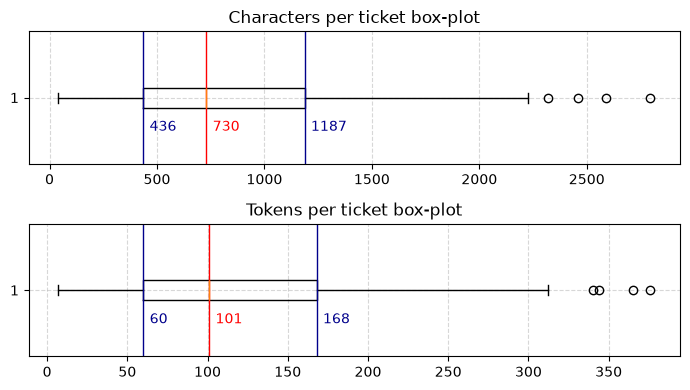

In [64]:
chars = cleaned_tickets_df["full_text"].str.len()
tokens = cleaned_tickets_df["full_text"].str.split(" ").str.len()

plt.clf()
fig, axs = plt.subplots(2, 1, figsize=(7, 4))

# Characters per ticket box-plot
axs[0].set_title("Characters per ticket box-plot")
axs[0].boxplot(chars, orientation="horizontal")
axs[0].grid(linestyle="--", alpha=0.5)

median_chars = chars.median()
axs[0].axvline(median_chars, color="red", linestyle="-", linewidth=1)
axs[0].text(median_chars + axs[0].get_xlim()[1] * 0.01, axs[0].get_ylim()[1] / 2, f"{median_chars:.0f}", color="red")

percentile_25_chars = chars.quantile(0.25)
axs[0].axvline(percentile_25_chars, color="darkblue", linestyle="-", linewidth=1)
axs[0].text(percentile_25_chars + axs[0].get_xlim()[1] * 0.01, axs[0].get_ylim()[1] / 2, f"{percentile_25_chars:.0f}", color="darkblue")

percentile_75_chars = chars.quantile(0.75)
axs[0].axvline(percentile_75_chars, color="darkblue", linestyle="-", linewidth=1)
axs[0].text(percentile_75_chars + axs[0].get_xlim()[1] * 0.01, axs[0].get_ylim()[1] / 2, f"{percentile_75_chars:.0f}", color="darkblue")

# Tokens per ticket box-plot
axs[1].set_title("Tokens per ticket box-plot")
axs[1].boxplot(tokens, orientation="horizontal")
axs[1].grid(linestyle="--", alpha=0.5)

median_tokens = tokens.median()
axs[1].axvline(median_tokens, color="red", linestyle="-", linewidth=1)
axs[1].text(median_tokens + axs[1].get_xlim()[1] * 0.01, axs[1].get_ylim()[1] / 2, f"{median_tokens:.0f}", color="red")

percentile_25_tokens = tokens.quantile(0.25)
axs[1].axvline(percentile_25_tokens, color="darkblue", linestyle="-", linewidth=1)
axs[1].text(percentile_25_tokens + axs[1].get_xlim()[1] * 0.01, axs[1].get_ylim()[1] / 2, f"{percentile_25_tokens:.0f}", color="darkblue")

percentile_75_tokens = tokens.quantile(0.75)
axs[1].axvline(percentile_75_tokens, color="darkblue", linestyle="-", linewidth=1)
axs[1].text(percentile_75_tokens + axs[1].get_xlim()[1] * 0.01, axs[1].get_ylim()[1] / 2, f"{percentile_75_tokens:.0f}", color="darkblue")

plt.tight_layout()
plt.show()

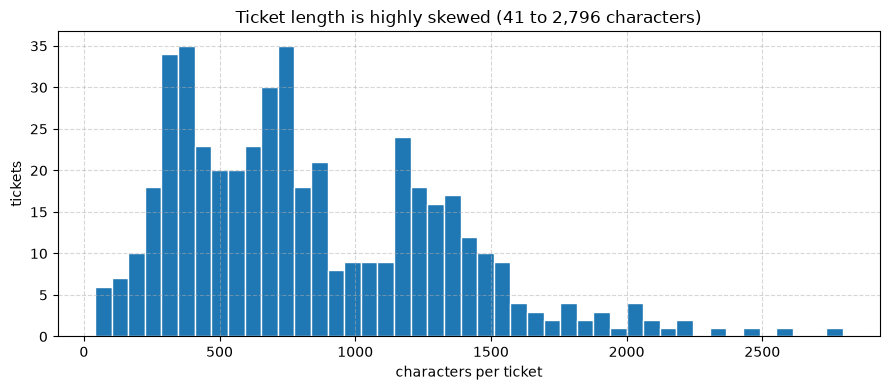

In [29]:
plt.clf()
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(cleaned_tickets_df["full_text"].str.len(), bins=45, color="tab:blue", edgecolor="white")
ax.set_xlabel("characters per ticket")
ax.set_ylabel("tickets")
ax.set_title("Ticket length distribution")
ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Terms frequency analysis

In [104]:
document_tokens_counter = CountVectorizer(
    binary=True, 
    stop_words=TOKEN_STOPWORDS, 
    token_pattern=TOKEN_PATTERN
)

document_tokens_matrix = document_tokens_counter.fit_transform(cleaned_tickets_df["full_text"])
vocabulary = document_tokens_counter.get_feature_names_out()
tokens_frequency = np.asarray(document_tokens_matrix.sum(axis=0)).ravel() / NUMBER_DOCS
tokens_frequency_order = np.argsort(-tokens_frequency)

In [ ]:
terms_frequency = pd.DataFrame({
    "term": vocabulary[tokens_frequency_order], 
    "df_frac": tokens_frequency[tokens_frequency_order]
})
terms_frequency.index = np.arange(1, len(terms_frequency) + 1)

terms_frequency

,term,df_frac
1,name,0.934461
2,suporte,0.892178
3,obrigado,0.780127
4,cliente,0.737844
5,atenciosamente,0.727273
...,...,...
3259,abordem,0.002114
3260,abordará,0.002114
3261,abordado,0.002114
3262,22,0.002114


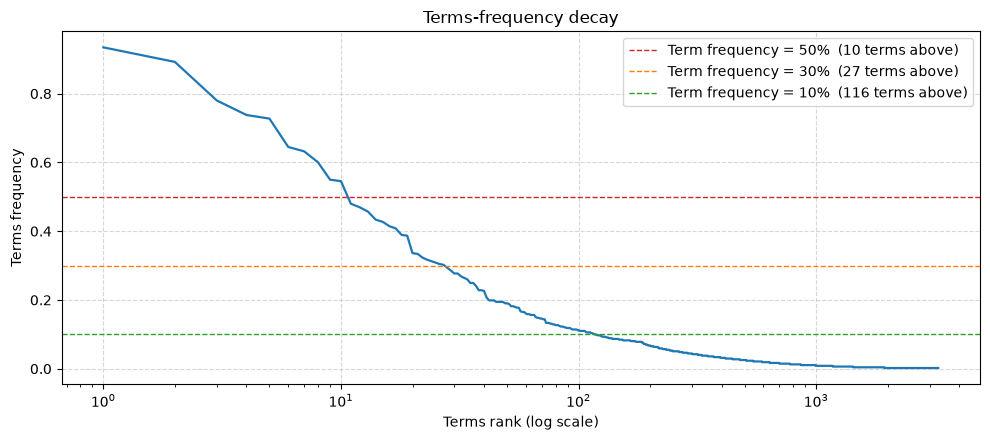

In [117]:
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(np.arange(1, len(terms_frequency) + 1), np.sort(terms_frequency["df_frac"])[::-1], lw=1.6)
ax.set_xscale("log")
for threshold, colour in [(0.5, "tab:red"), (0.3, "tab:orange"), (0.1, "tab:green")]:
    ax.axhline(threshold, ls="--", lw=1, color=colour,
               label=f"Term frequency = {threshold:.0%}  ({(terms_frequency['df_frac'] > threshold).sum()} terms above)")
ax.set_xlabel("Terms rank (log scale)")
ax.set_ylabel("Terms frequency")
ax.set_title("Terms-frequency decay")
ax.grid(linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

### Phrasal boilerplate analysis

Unigram frequency understates the problem. The real ceremony in these tickets is multi-word —
*"espero que esta mensagem o encontre bem"*, *"aguardo sua resposta rápida"* — and no unigram filter can
remove a phrase while keeping its component words available elsewhere.

In [129]:
document_phrase_counter = CountVectorizer(
    binary=True, 
    stop_words=TOKEN_STOPWORDS,
    ngram_range=(3,10), # Phrases of 3 to 10 words
    token_pattern=TOKEN_PATTERN
)

document_phrases_matrix = document_phrase_counter.fit_transform(cleaned_tickets_df["full_text"])
phrases = document_phrase_counter.get_feature_names_out()
document_phrases_frequency = np.asarray(document_phrases_matrix.sum(axis=0)).ravel() / NUMBER_DOCS
document_phrases_frequency_order = np.argsort(-document_phrases_frequency)

In [130]:
phrases_frequency = pd.DataFrame({
    "term": phrases[document_phrases_frequency_order], 
    "df_frac": document_phrases_frequency[document_phrases_frequency_order]
})
phrases_frequency.index = np.arange(1, len(phrases_frequency) + 1)

phrases_frequency

,term,df_frac
1,espero mensagem encontre bem,0.295983
2,espero mensagem encontre,0.295983
3,mensagem encontre bem,0.295983
4,caro suporte cliente,0.289641
5,caro time suporte,0.241015
...,...,...
227005,10 microsoft surface pro poderia fornecer,0.002114
227006,10 microsoft surface pro poderia,0.002114
227007,10 microsoft surface pro,0.002114
227008,10 microsoft surface,0.002114


Knowing *what* the boilerplate is does not yet tell us how to remove it safely. A global find-and-replace
for `"obrigado"` would also delete it from a sentence like *"Obrigado pela ajuda até agora, mas o problema
continua"* — destroying real content.

So measure **where** each boilerplate family occurs, as a fraction of document length. If greetings
cluster near 0.0 and signoffs near 1.0 while genuine signal spreads through the middle, then positional
rules (cut the first line, cut from the signoff to the end) are both safer and simpler than global
substitution. A signal control (`problema|erro|falha`) is included for contrast.

                             probe  tickets    df  median_pos  first_15%  last_25%
  greeting: caro/prezado + suporte      391 0.827       0.061      0.936     0.000
           greeting: olá/saudações        3 0.006       0.000      1.000     0.000
 pleasantry: espero...encontre bem      148 0.313       0.078      0.946     0.000
  pleasantry: aguardo sua resposta       89 0.188       0.916      0.000     1.000
 pleasantry: obrigado pela atenção      150 0.317       0.903      0.000     1.000
           signoff: atenciosamente      344 0.727       0.966      0.000     1.000
signoff: cordialmente/cumprimentos       12 0.025       0.941      0.000     1.000
    closing: obrigado (standalone)      369 0.780       0.912      0.000     1.000
           placeholder: <name> etc      447 0.945       0.970      0.034     0.834
   CONTROL - signal: problema/erro      294 0.622       0.372      0.278     0.141


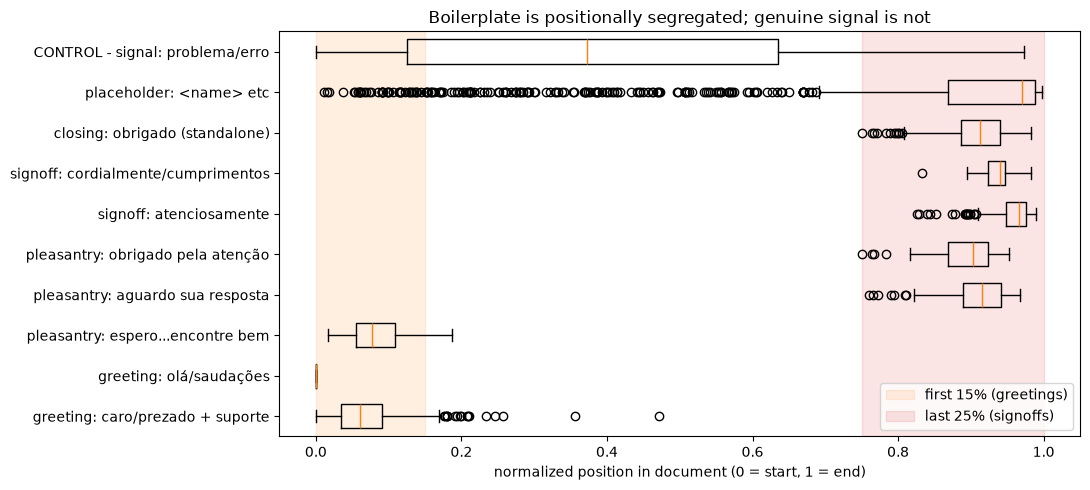

In [133]:
# Probe families of boilerplate, plus one genuine-signal control for contrast.
PROBES = {
    "greeting: caro/prezado + suporte":   r"(?i)\b(caro|cara|prezad[oa]s?)\b[^.\n]{0,60}\b(suporte|atendimento|equipe|time|cliente)\b",
    "greeting: olá/saudações":            r"(?i)^\s*(ol[áa]|sauda[çc][õo]es)\b",
    "pleasantry: espero...encontre bem":  r"(?i)espero que (esta|este)[^.]{0,40}encontre[^.]{0,20}bem",
    "pleasantry: aguardo sua resposta":   r"(?i)aguard(o|ando|amos)[^.]{0,30}resposta",
    "pleasantry: obrigado pela atenção":  r"(?i)obrigad[oa][^.]{0,40}aten[çc][ãa]o",
    "signoff: atenciosamente":            r"(?i)\batenciosamente\b",
    "signoff: cordialmente/cumprimentos": r"(?i)\b(cordialmente|melhores cumprimentos|atentamente)\b",
    "closing: obrigado (standalone)":     r"(?i)\bobrigad[oa]\b",
    "placeholder: <name> etc":            r"<[^<>\n]{1,60}>",
    "CONTROL - signal: problema/erro":    r"(?i)\b(problema|erro|falha|defeito)\b",
}

positions, rows = {}, []
for label, pattern in PROBES.items():
    rx = re.compile(pattern, re.M)
    found, n_tickets = [], 0
    for text in cleaned_tickets_df["full_text"]:
        matches = list(rx.finditer(text))
        if matches:
            n_tickets += 1
            found.extend(m.start() / len(text) for m in matches)
    if not found:
        continue
    found = np.array(found)
    positions[label] = found
    rows.append({"probe": label, "tickets": n_tickets, "df": n_tickets / NUMBER_DOCS,
                 "median_pos": np.median(found),
                 "first_15%": (found < 0.15).mean(), "last_25%": (found > 0.75).mean()})

print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, ax = plt.subplots(figsize=(11, 5))
labels = list(positions)
ax.boxplot([positions[l] for l in labels], orientation="horizontal",
           tick_labels=labels, widths=.6)
ax.axvspan(0, 0.15, color="tab:orange", alpha=.12, label="first 15% (greetings)")
ax.axvspan(0.75, 1.0, color="tab:red", alpha=.12, label="last 25% (signoffs)")
ax.set_xlabel("normalized position in document (0 = start, 1 = end)")
ax.set_title("Boilerplate is positionally segregated; genuine signal is not")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()